In [1]:
import re
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable

C:\Users\x12la\AppData\Local\Temp\ipykernel_8964\658706449.py:3: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [3]:
locus = gpd.read_file("LOCUS_IL_Idling.shp").to_crs("EPSG:4326")
warehouses = gpd.read_file("../WarehouseMidwest.shp").to_crs("EPSG:4326")
truck_stops = gpd.read_file("Truck_Stop_Parking.shp").to_crs("EPSG:4326")
terminals = gpd.read_file("../LOCUS/Intermodal_Freight_Facilities_Pipeline_Terminals.shp").to_crs("EPSG:4326")
freight_rail = gpd.read_file("../LOCUS/Intermodal_Freight_Facilities_Rail_TOFC_COFC.shp").to_crs("EPSG:4326")
allroads = gpd.read_file("../tl_2019_17_prisecroads.shp").to_crs("EPSG:4326")
cmap_cty = gpd.read_file("../cmap_cty.shp").to_crs("EPSG:4326")

study_boundary = locus.dissolve()
cmap_boundary = cmap_cty.dissolve()

In [4]:
# Count warehouses within model grid 
grid = locus.copy().reset_index(drop=True)
grid["grid_id"] = grid.index

joined = gpd.sjoin(warehouses[["geometry"]], grid[["grid_id", "geometry"]], how="left", predicate="within")
warehouse_counts = joined.groupby("grid_id").size()

grid["wh_count"] = grid["grid_id"].map(warehouse_counts).fillna(0).astype(int)

In [18]:
# pull out interstates and highways 
roads_I = allroads[allroads["RTTYP"] == "I"].copy()
roads_S = allroads[allroads["RTTYP"] == "S"].copy()

# roads i want to plot 
major_interstates = [55, 57, 80, 88, 90, 94, 294, 355]

In [37]:
# clip data to CMAP domain
grid_cmap = gpd.clip(grid, cmap_boundary)
allroads_cmap = gpd.clip(allroads, cmap_boundary)
allroads_cmap = allroads_cmap[allroads_cmap.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()
cmap_roads_I = allroads_cmap[allroads_cmap["RTTYP"] == "I"].copy()
cmap_roads_S = allroads_cmap[allroads_cmap["RTTYP"] == "S"].copy()

truck_stops_cmap = gpd.clip(truck_stops, cmap_boundary)
terminals_cmap = gpd.clip(terminals, cmap_boundary)
freight_rail_cmap = gpd.clip(freight_rail, cmap_boundary)

In [34]:
def set_extent(ax, boundary, pad=0.06):
    xmin, ymin, xmax, ymax = boundary.total_bounds
    dx, dy = (xmax - xmin) * pad, (ymax - ymin) * pad
    ax.set_xlim(xmin - dx, xmax + dx)
    ax.set_ylim(ymin - dy, ymax + dy)


def add_cmap_base(ax):
    cmap_cty.plot(ax=ax, facecolor="#f7f7f7", edgecolor="black", linewidth=0.7, zorder=0,alpha=.5)
    cmap_cty.boundary.plot(ax=ax, color="black", linewidth=0.7, alpha=0.7, zorder=5)
    cmap_boundary.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=6)
    set_extent(ax, cmap_boundary)
    ax.set_axis_off()


def add_county_labels(ax, counties, fontsize=16):
    for _, row in counties.iterrows():
        point = row.geometry.representative_point()
        ax.text(point.x, point.y + 0.03, row["NAME"], fontsize=fontsize, color="#555555", ha="center", va="center",
                alpha=0.85, zorder=40, path_effects=[pe.Stroke(linewidth=2, foreground="white"), pe.Normal()])

# generated with the help of ChatGPT
def add_interstate_labels(ax, roads, interstate_numbers, fontsize=9, label_every=3, min_length=0.03):
    roads = roads.dropna(subset=["FULLNAME"]).copy()
    roads["INTERSTATE"] = roads["FULLNAME"].astype(str).str.extract(r"(?:I|INTERSTATE)[\s\-]*(\d+)", flags=re.IGNORECASE)[0]
    roads = roads[roads["INTERSTATE"].isin(map(str, interstate_numbers))]
    for number, group in roads.groupby("INTERSTATE"):
        lines = []
        for geom in group.geometry:
            if geom is None or geom.is_empty: continue
            parts = [geom] if geom.geom_type == "LineString" else list(geom.geoms) if geom.geom_type == "MultiLineString" else []
            lines.extend(line for line in parts if line.length >= min_length)
        lines = sorted(lines, key=lambda line: (line.centroid.x, line.centroid.y))

        for line in lines[::label_every]:
            point = line.interpolate(0.5, normalized=True)
            ax.text(point.x, point.y, f"I-{number}", fontsize=fontsize, fontweight="bold", color="dimgray",
                    ha="center", va="center", zorder=50,
                    path_effects=[pe.Stroke(linewidth=2, foreground="white"), pe.Normal()])

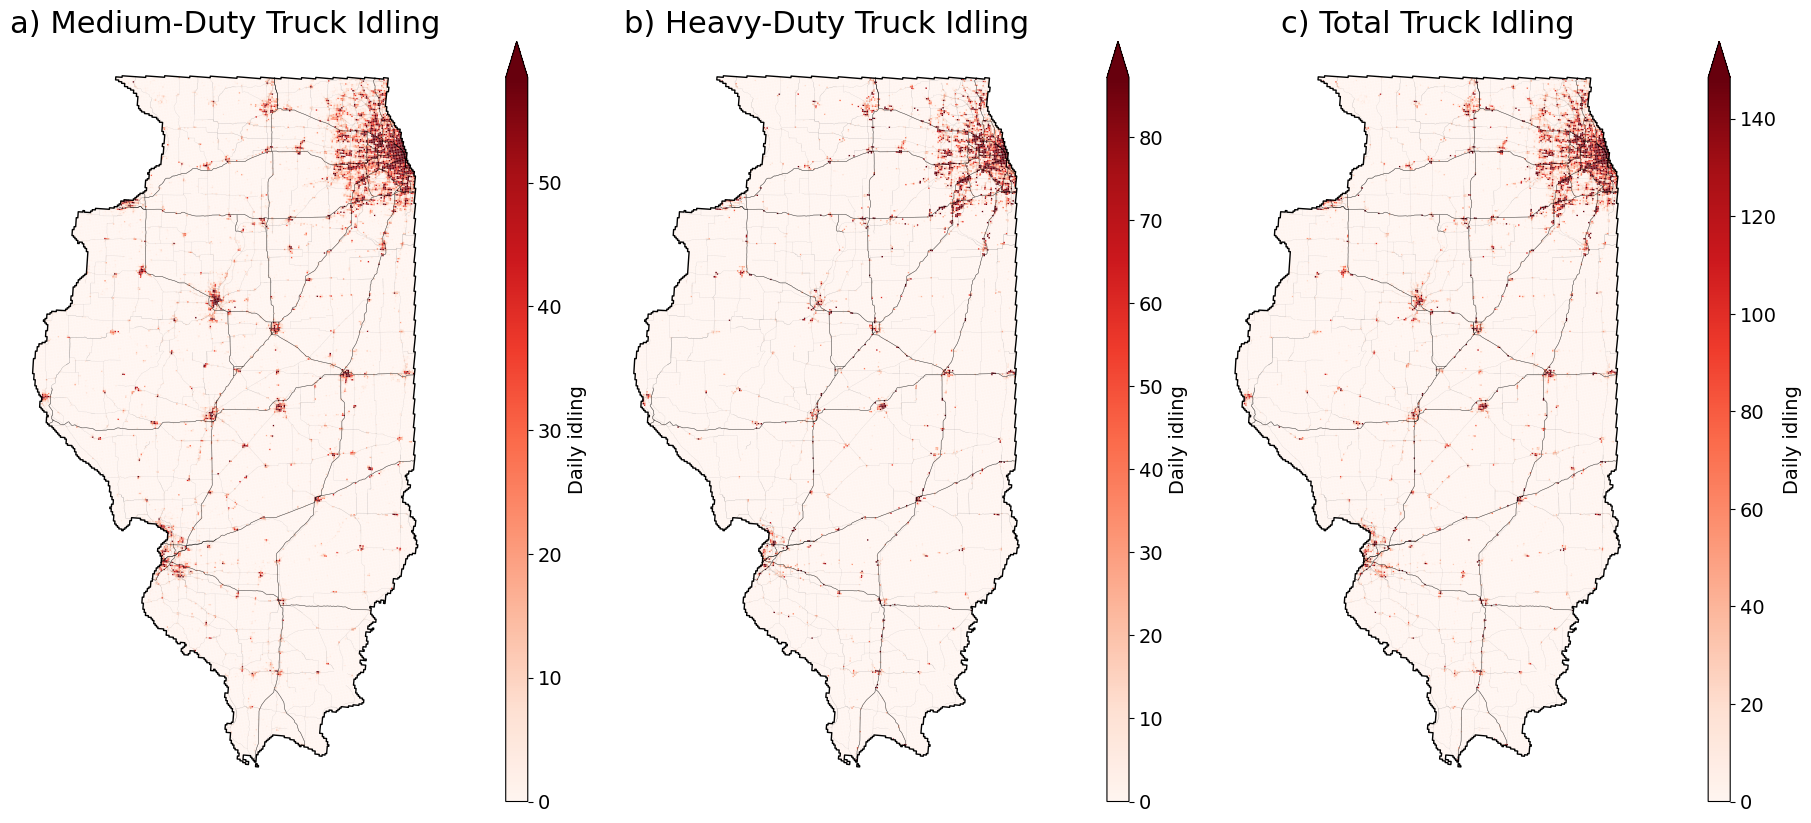

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8), constrained_layout=True)

def plot_idling(ax, col, title):
    locus.plot(ax=ax, column=col, cmap="Reds", edgecolor="none", vmin=0, vmax=locus[col].quantile(0.99))
    roads_I.plot(ax=ax, color="black", linewidth=0.35, alpha=0.45)
    roads_S.plot(ax=ax, color="grey", linewidth=0.20, alpha=0.30)
    study_boundary.boundary.plot(ax=ax, color="black", linewidth=1)
    vmax = locus[col].quantile(0.99)
    sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, vmax), cmap="Reds")
    cax = make_axes_locatable(ax).append_axes("right", size="4%", pad=0.05)
    cbar = plt.colorbar(sm, cax=cax, extend="max")
    cbar.set_label("Daily idling", fontsize=14)
    cbar.ax.tick_params(labelsize=14)
    ax.set_title(title, fontsize=22)
    ax.set_axis_off()

plot_idling(axes[0], "MDT_avg_da", "a) Medium-Duty Truck Idling")
plot_idling(axes[1], "HDT_avg_da", "b) Heavy-Duty Truck Idling")
plot_idling(axes[2], "Total_avg_", "c) Total Truck Idling")

plt.savefig("IL_idling_only_3panel.png", dpi=500, bbox_inches="tight")
plt.savefig("IL_idling_only_3panel.pdf", dpi=500, bbox_inches="tight")
plt.show()

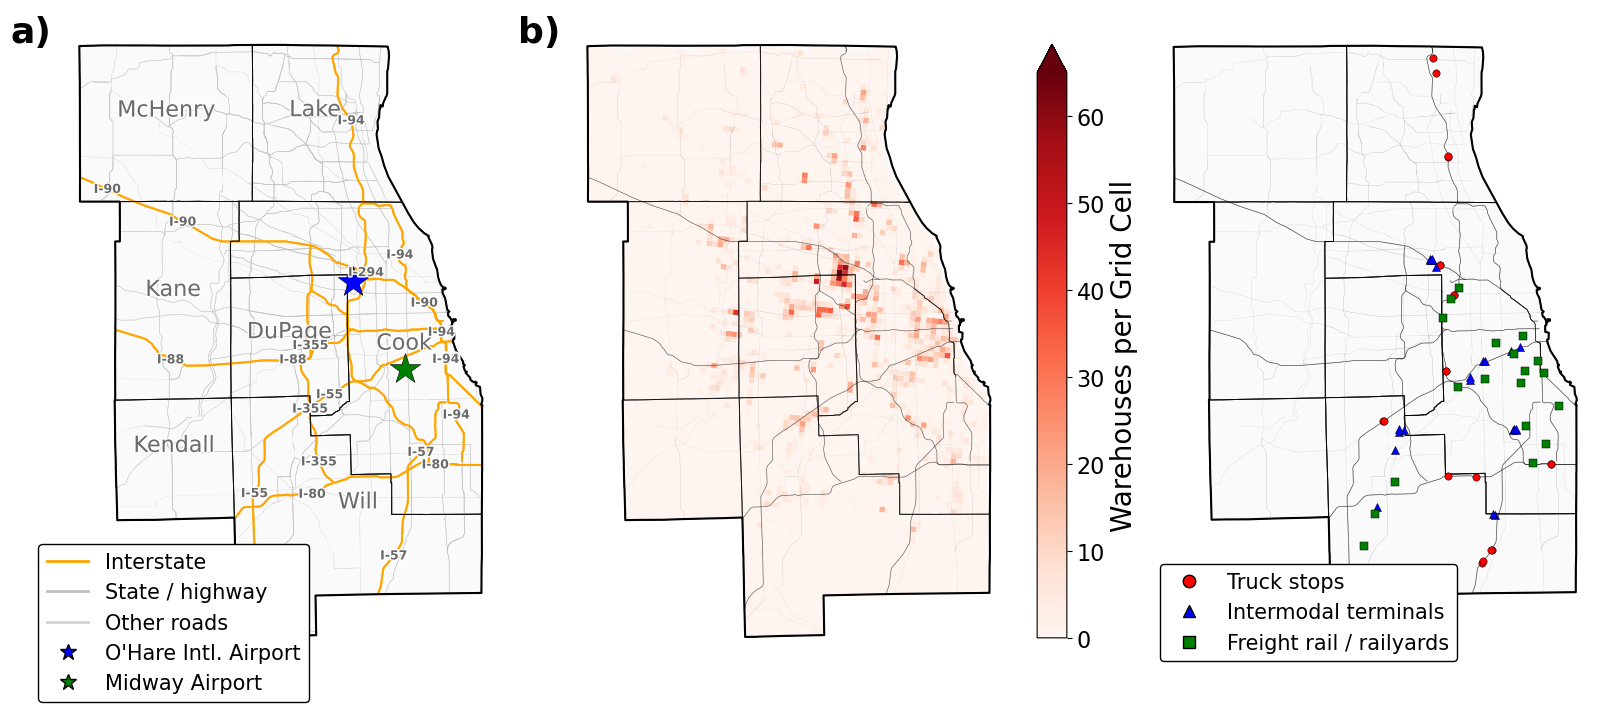

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8), constrained_layout=True)
ax0, ax1, ax2 = axes

# PANEL A: ROAD NETWORK AND AIRPORTS

add_cmap_base(ax0)

allroads_cmap.plot(ax=ax0, color="lightgrey", linewidth=0.25, alpha=0.55, zorder=1)
cmap_roads_S.plot(ax=ax0, color="silver", linewidth=0.45, alpha=0.85, zorder=2)
cmap_roads_I.plot(ax=ax0, color="orange", linewidth=1.4, alpha=0.95, zorder=3)
add_county_labels(ax0, cmap_cty)
add_interstate_labels(ax0, cmap_roads_I, major_interstates)
ax0.scatter(-87.904724, 41.978611, marker="*", s=530, color="blue", edgecolor="black", linewidth=0.4, zorder=10)
ax0.scatter(-87.7522, 41.7868, marker="*", s=530, color="green", edgecolor="black", linewidth=0.4, zorder=10)
ax0.text(-0.10, 0.95, "a)", transform=ax0.transAxes, fontsize=26, fontweight="bold")

road_legend = [
    Line2D([0], [0], color="orange", lw=2, label="Interstate"),
    Line2D([0], [0], color="silver", lw=2, label="State / highway"),
    Line2D([0], [0], color="lightgrey", lw=2, label="Other roads"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="blue", markeredgecolor="black", markersize=12, label="O'Hare Intl. Airport"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="green", markeredgecolor="black", markersize=12, label="Midway Airport"),]

leg = ax0.legend(handles=road_legend, loc="lower left", bbox_to_anchor=(-0.06, -0.06), fontsize=15, frameon=True)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_alpha(1)
leg.set_zorder(1000)

# PANEL B: WAREHOUSES PER LOCUS GRID CELL

add_cmap_base(ax1)

grid_cmap.plot(ax=ax1, column="wh_count", cmap="Reds", edgecolor="none", legend=True,
               legend_kwds={"label": "Gridded Warehouses Count","extend":"max" ,"shrink": 0.75})
# Make tick marks and colorbar label larger
cbar_ax = fig.axes[-1]
cbar_ax.tick_params(labelsize=16)
cbar_ax.set_ylabel("Warehouses per Grid Cell", fontsize=20)
cmap_roads_I.plot(ax=ax1, color="black", linewidth=0.45, alpha=0.35, zorder=5)
cmap_roads_S.plot(ax=ax1, color="grey", linewidth=0.20, alpha=0.25, zorder=5)

ax1.text(-0.10, 0.95, "b)", transform=ax1.transAxes, fontsize=26, fontweight="bold")

# PANEL C: TRUCK-SUPPORTING INFRASTRUCTURE

add_cmap_base(ax2)

cmap_roads_I.plot(ax=ax2, color="black", linewidth=0.45, alpha=0.45, zorder=7)
cmap_roads_S.plot(ax=ax2, color="grey", linewidth=0.25, alpha=0.30, zorder=7)
truck_stops_cmap.plot(ax=ax2, color="red", marker="o", markersize=28, edgecolor="black", linewidth=0.35, zorder=10)
terminals_cmap.plot(ax=ax2, color="blue", marker="^", markersize=34, edgecolor="black", linewidth=0.35, zorder=10)
freight_rail_cmap.plot(ax=ax2, color="green", marker="s", markersize=28, edgecolor="black", linewidth=0.35, zorder=10)

infra_legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markeredgecolor="black", markersize=9, label="Truck stops"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="blue", markeredgecolor="black", markersize=9, label="Intermodal terminals"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="green", markeredgecolor="black", markersize=9, label="Freight rail / railyards"),]

leg = ax2.legend(handles=infra_legend, loc="lower left", fontsize=15, frameon=True)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_alpha(1)
leg.set_zorder(1000)

plt.savefig("Fig1_CMAP_truck_network_warehouse_infrastructure.png", dpi=500, bbox_inches="tight")
plt.savefig("Fig1_CMAP_truck_network_warehouse_infrastructure.tiff", dpi=500, bbox_inches="tight")
plt.show()